In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv('car_data_cleaned_new.csv')
df.head()

,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Price_EGP,fabrika,...,rear_camera,cruise,alloy,push_start,abs,airbags,air_condition,bluetooth,full_option,first_owner
0,Ford,Escort,130000,1998,Benzine,Manual,1300,Sedan,140000.0,1,...,0,0,0,0,0,0,0,0,0,0
1,Speranza,A113,83000,2012,Benzine,Manual,1300,Hatchback,243000.0,0,...,0,0,0,0,0,0,1,0,0,0
2,Honda,City,100000,2008,Benzine,Automatic,1500,Sedan,240000.0,0,...,0,0,0,0,0,0,0,0,0,0
3,Volkswagen,Pointer,180000,2006,Benzine,Manual,1600,Hatchback,155000.0,1,...,0,0,0,0,0,0,0,0,0,0
4,Geely,Emgrand 7,215000,2017,Diesel,Manual,1600,Sedan,380000.0,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5123 entries, 0 to 5122
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 5123 non-null   object 
 1   Model                 5123 non-null   object 
 2   Kilometers            5123 non-null   int64  
 3   Year                  5123 non-null   int64  
 4   Fuel Type             5123 non-null   object 
 5   Transmission Type     5123 non-null   object 
 6   Engine Capacity (CC)  5123 non-null   int64  
 7   Body Type             5123 non-null   object 
 8   Price_EGP             5123 non-null   float64
 9   fabrika               5123 non-null   int64  
 10  zero_condition        5123 non-null   int64  
 11  rasha                 5123 non-null   int64  
 12  accident              5123 non-null   int64  
 13  excellent_condition   5123 non-null   int64  
 14  service_center        5123 non-null   int64  
 15  full_service_history 

In [123]:
x=df.drop('Price_EGP', axis=1)
y=df['Price_EGP']   

In [124]:
x.head()

,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,fabrika,zero_condition,...,rear_camera,cruise,alloy,push_start,abs,airbags,air_condition,bluetooth,full_option,first_owner
0,Ford,Escort,130000,1998,Benzine,Manual,1300,Sedan,1,0,...,0,0,0,0,0,0,0,0,0,0
1,Speranza,A113,83000,2012,Benzine,Manual,1300,Hatchback,0,1,...,0,0,0,0,0,0,1,0,0,0
2,Honda,City,100000,2008,Benzine,Automatic,1500,Sedan,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Volkswagen,Pointer,180000,2006,Benzine,Manual,1600,Hatchback,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Geely,Emgrand 7,215000,2017,Diesel,Manual,1600,Sedan,1,1,...,0,0,0,0,0,0,0,0,0,0


In [125]:
y.head()

0    140000.0
1    243000.0
2    240000.0
3    155000.0
4    380000.0
Name: Price_EGP, dtype: float64

In [126]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [127]:
col=x_train[['Engine Capacity (CC)', 'Kilometers']]
skewness = col.skew().sort_values(ascending=False)
print(skewness)

Engine Capacity (CC)    3.693116
Kilometers              0.636750
dtype: float64


In [128]:
skewness = y_train.skew()
print(skewness)

1.3821994189477844


In [129]:
# we wont transform year column as its a categorical feature as numbers
# also binary columns dont need transformation
# we will only transform Engine Capacity (CC),Kilometers and Price_EGP
# Engine Capacity is higlhy skewed to right so we will use log1p transformation
# for price we will use log1p transformation as its highly skewed to right

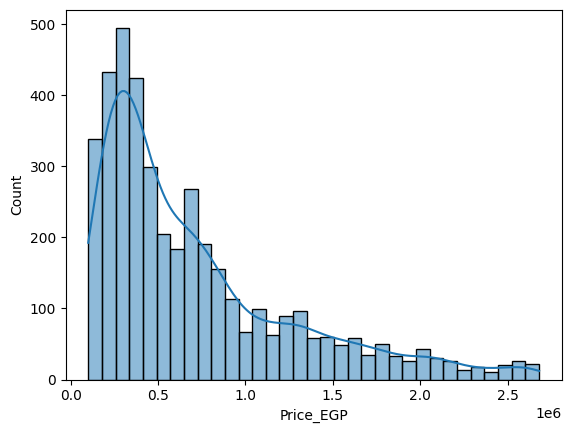

In [130]:
sns.histplot(y_train, kde=True)
plt.show()

In [131]:
# we will make our pipline to log transform and hot one encode our categorical columns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

categorical_features = ['Brand', 'Model', 'Fuel Type', 'Transmission Type', 'Body Type']
log_features = ['Engine Capacity (CC)']
sqrt_features = ['Kilometers']

log_transformer = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False))
])
sqrt_transformer = Pipeline([
    ('sqrt', FunctionTransformer(np.sqrt, validate=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('log', log_transformer, log_features),
        ('sqrt', sqrt_transformer, sqrt_features)
    ],
    remainder='passthrough'
)


In [132]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [133]:
# we will use xgboost model as it can handle many features 
# also MAE is better for us beacuse it gives error in same unit EGP so we can understnad how our model is doing


In [134]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=XGBRegressor(random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])


model.fit(x_train, y_train)
model_predict = model.predict(x_train)

mse = mean_squared_error(y_train, model_predict)
mae = mean_absolute_error(y_train, model_predict)
print(f"Train MSE: {mse}")
print(f"Train MAE: {mae}")

Train MSE: 11184941562.419424
Train MAE: 64013.20016433321


In [135]:
# we got a 64k price diff in our predictions on train we will fine tune or model
from sklearn.model_selection import GridSearchCV

full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=XGBRegressor(random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])


xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_grid = GridSearchCV(
    estimator=full_pipe,
    param_grid={
        'regressor__regressor__n_estimators': [100, 300, 500],
        'regressor__regressor__max_depth': [3, 5, 7],
        'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__regressor__subsample': [0.8, 1],
        'regressor__regressor__colsample_bytree': [0.8, 1]
    },
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

xgb_grid.fit(x_train, y_train)
xgb_grid_predict = xgb_grid.predict(x_train)
mse = mean_squared_error(y_train, xgb_grid_predict)
mae = mean_absolute_error(y_train, xgb_grid_predict)

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB CV Score (MAE):", -xgb_grid.best_score_)
print(f"Train MSE: {mse}")
print(f"Train MAE: {mae}")

Best XGB Params: {'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_depth': 7, 'regressor__regressor__n_estimators': 500, 'regressor__regressor__subsample': 0.8}
Best XGB CV Score (MAE): 87566.13471500974
Train MSE: 4518535376.181362
Train MAE: 41502.3672732888


In [136]:
# our model improved with fine tune with 40k price diff error 
# evlaluate on test set next
xgb_test_predict = xgb_grid.predict(x_test)
mse_test = mean_squared_error(y_test, xgb_test_predict)
mae_test = mean_absolute_error(y_test, xgb_test_predict)
print(f"Test MSE: {mse_test}")
print(f"Test MAE: {mae_test}")  

Test MSE: 21157676974.541115
Test MAE: 85071.38658536585


c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [137]:
# our model is now giving around 40k EGP error on train data
# on test data its giving around 80k EGP error which is acceptable for used car prices prediction
# beacause used car prices can vary widely based on many factors not captured in the data
# might be some overfitting but is acceptable for regression task in this case
# save the modeland preprocessor
import joblib
joblib.dump(xgb_grid, 'car_price_model_xgb.pkl')
joblib.dump(preprocessor, 'car_price_preprocessor.pkl')

['car_price_preprocessor.pkl']